   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.9 MB/s eta 0:00:00
Upload your Semeval2018-Task2-EmojiPrediction__1_.zip file:


Saving Semeval2018-Task2-EmojiPrediction (1).zip to Semeval2018-Task2-EmojiPrediction (1).zip
Extracted: ['.DS_Store', 'results', 'test', 'README.txt', 'trial', 'train', 'mapping']

20 emoji classes:
   0  ❤  _red_heart_
   1  😍  _smiling_face_with_hearteyes_
   2  😂  _face_with_tears_of_joy_
   3  💕  _two_hearts_
   4  🔥  _fire_
   5  😊  _smiling_face_with_smiling_eyes_
   6  😎  _smiling_face_with_sunglasses_
   7  ✨  _sparkles_
   8  💙  _blue_heart_
   9  😘  _face_blowing_a_kiss_
  10  📷  _camera_
  11  🇺🇸  _United_States_
  12  ☀  _sun_
  13  💜  _purple_heart_
  14  😉  _winking_face_
  15  💯  _hundred_points_
  16  😁  _beaming_face_with_smiling_eyes_
  17  🎄  _Christmas_tree_
  18  📸  _camera_with_flash_
  19  😜  _winking_face_with_tongue_

Train: 42,500  |  Val: 7,500  |  Test: 50,000


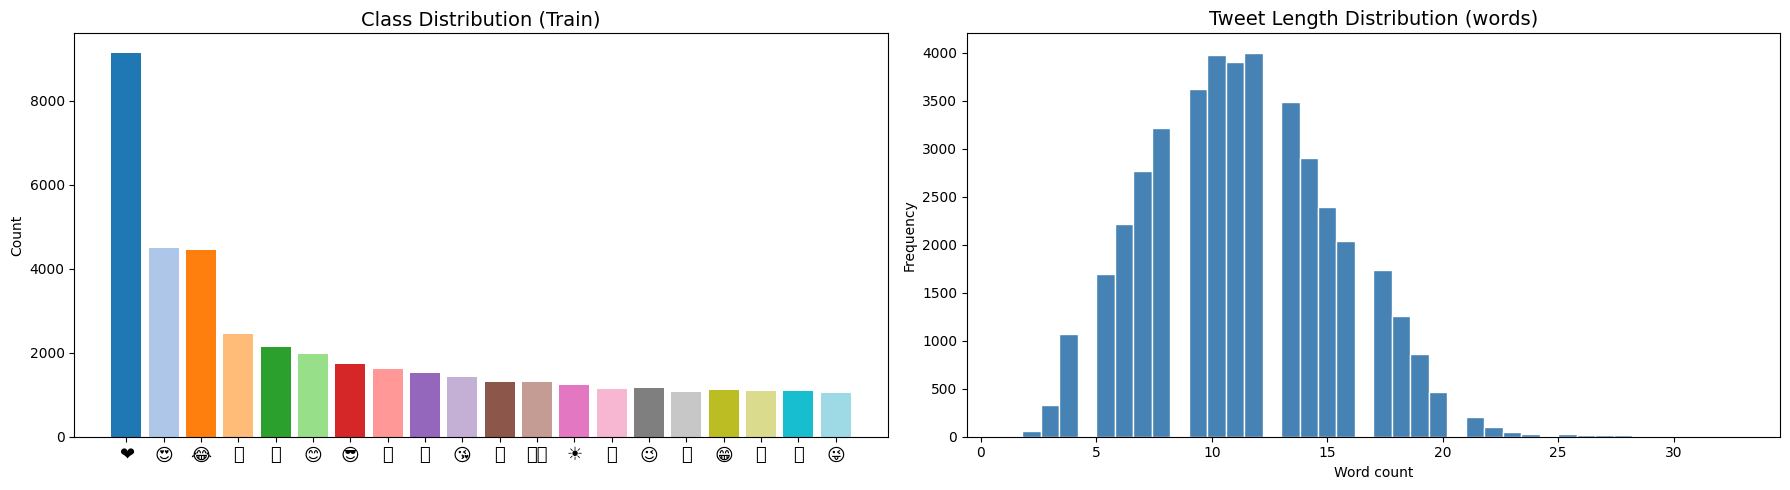

Avg tweet length: 11.3 words

Sample preprocessing:
  RAW  : protect your magic @ Wynnwood
  CLEAN: protect your magic wynnwood
  LABEL: ✨  _sparkles_

  RAW  : A Hogwarts por favor (si, amo Harry) #HarryPotter #TheWizardingWorld @
  CLEAN: a hogwarts por favor si amo harry harrypotter thewizardingworld the wi
  LABEL: 😍  _smiling_face_with_hearteyes_

  RAW  : Victoria Love the @user foundation! #kenyettagreene #makeupartist #dcm
  CLEAN: victoria love the foundation kenyettagreene makeupartist dcmakeupartis
  LABEL: ✨  _sparkles_



In [1]:
# ============================================================
# SECTION 1: Setup, Data Loading & EDA
# ============================================================

# Install dependencies
!pip install -q transformers datasets emoji scikit-learn seaborn torch accelerate -U

import os, zipfile, re, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Upload & extract dataset ─────────────────────────────────
from google.colab import files
print("Upload your Semeval2018-Task2-EmojiPrediction__1_.zip file:")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('data/')

DATA_ROOT = 'data/Semeval2018-Task2-EmojiPrediction'
print("Extracted:", os.listdir(DATA_ROOT))

# ── Load emoji mapping ───────────────────────────────────────
def load_mapping(path):
    mapping = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                mapping[int(parts[0])] = {'emoji': parts[1], 'name': parts[2]}
    return mapping

US_MAPPING = load_mapping(f'{DATA_ROOT}/mapping/us_mapping.txt')
print(f"\n20 emoji classes:")
for k, v in US_MAPPING.items():
    print(f"  {k:2d}  {v['emoji']}  {v['name']}")

# ── Load trial & test splits ─────────────────────────────────
def load_split(text_path, label_path):
    with open(text_path, encoding='utf-8') as f:
        texts = [l.strip() for l in f]
    with open(label_path, encoding='utf-8') as f:
        labels = [int(l.strip()) for l in f]
    assert len(texts) == len(labels)
    return pd.DataFrame({'text': texts, 'label': labels})

trial_df = load_split(f'{DATA_ROOT}/trial/us_trial.text',
                      f'{DATA_ROOT}/trial/us_trial.labels')
test_df  = load_split(f'{DATA_ROOT}/test/us_test.text',
                      f'{DATA_ROOT}/test/us_test.labels')

# Split trial into train/val (full train data needs crawling)
train_df, val_df = train_test_split(trial_df, test_size=0.15,
                                    stratify=trial_df['label'],
                                    random_state=42)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")

# ── EDA plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

counts = train_df['label'].value_counts().sort_index()
emojis = [US_MAPPING[i]['emoji'] for i in counts.index]
axes[0].bar(range(len(counts)), counts.values, color=plt.cm.tab20.colors)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(emojis, fontsize=13)
axes[0].set_title('Class Distribution (Train)', fontsize=14)
axes[0].set_ylabel('Count')

train_df['length'] = train_df['text'].str.split().str.len()
axes[1].hist(train_df['length'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Tweet Length Distribution (words)', fontsize=14)
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(f"Avg tweet length: {train_df['length'].mean():.1f} words")

# ── Text preprocessing ───────────────────────────────────────
def preprocess_tweet(text):
    text = text.replace('&amp;', '&').replace('&lt;', '<').replace('&gt;', '>')
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r"[^a-zA-Z0-9'\s]", ' ', text)
    return ' '.join(text.split()).lower().strip()

for df in [train_df, val_df, test_df]:
    df['clean_text'] = df['text'].apply(preprocess_tweet)

print("\nSample preprocessing:")
for _, row in train_df.head(3).iterrows():
    print(f"  RAW  : {row['text'][:70]}")
    print(f"  CLEAN: {row['clean_text'][:70]}")
    print(f"  LABEL: {US_MAPPING[row['label']]['emoji']}  {US_MAPPING[row['label']]['name']}\n")

=== TF-IDF + Logistic Regression ===
Accuracy : 0.2956
Macro-F1 : 0.2044

                                    precision    recall  f1-score   support

                     ❤ _red_heart_       0.32      0.58      0.41     10798
   😍 _smiling_face_with_hearteyes_       0.20      0.26      0.23      4830
        😂 _face_with_tears_of_joy_       0.29      0.46      0.35      4534
                    💕 _two_hearts_       0.14      0.08      0.10      2605
                          🔥 _fire_       0.49      0.37      0.42      3716
😊 _smiling_face_with_smiling_eyes_       0.07      0.06      0.07      1613
  😎 _smiling_face_with_sunglasses_       0.16      0.10      0.12      1996
                      ✨ _sparkles_       0.28      0.14      0.18      2749
                    💙 _blue_heart_       0.19      0.07      0.11      1549
           😘 _face_blowing_a_kiss_       0.10      0.04      0.06      1175
                        📷 _camera_       0.16      0.11      0.13      1432
             

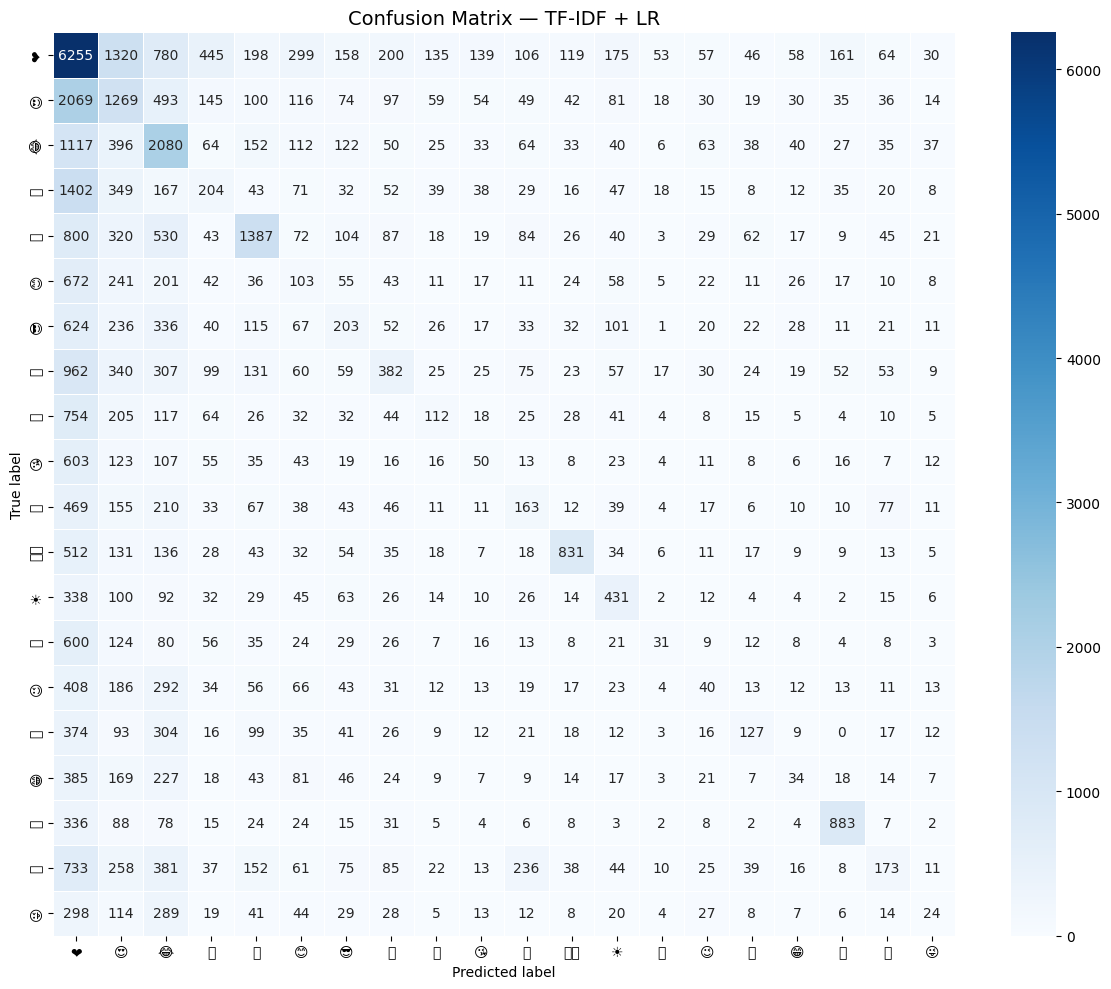

Model saved.


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)

# ── Vectorize ────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf   = tfidf.transform(val_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# ── Train ────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=5.0, solver='saga', n_jobs=-1)
lr.fit(X_train_tfidf, y_train)

# ── Evaluate ─────────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_tfidf)
target_names = [f"{US_MAPPING[i]['emoji']} {US_MAPPING[i]['name']}" for i in range(20)]

print("=== TF-IDF + Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Macro-F1 : {f1_score(y_test, y_pred_lr, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

# ── Confusion matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_lr)
emoji_labels = [US_MAPPING[i]['emoji'] for i in range(20)]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emoji_labels, yticklabels=emoji_labels,
            linewidths=0.5)
plt.title('Confusion Matrix — TF-IDF + LR', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Save model
with open('tfidf_lr_model.pkl', 'wb') as f:
    pickle.dump({'tfidf': tfidf, 'lr': lr, 'mapping': US_MAPPING}, f)
print("Model saved.")

Device: cuda
Vocabulary size: 40,000
Parameters: 7,556,245
Epoch 01/15 | Train Loss 2.8516 Acc 0.1844 | Val Loss 2.7625 Acc 0.2152 F1 0.0177
Epoch 02/15 | Train Loss 2.7560 Acc 0.2175 | Val Loss 2.6812 Acc 0.2404 F1 0.0587
Epoch 03/15 | Train Loss 2.6751 Acc 0.2451 | Val Loss 2.6120 Acc 0.2676 F1 0.0909
Epoch 04/15 | Train Loss 2.6000 Acc 0.2727 | Val Loss 2.5741 Acc 0.2817 F1 0.1201
Epoch 05/15 | Train Loss 2.5311 Acc 0.2970 | Val Loss 2.5510 Acc 0.2959 F1 0.1303
Epoch 06/15 | Train Loss 2.4699 Acc 0.3159 | Val Loss 2.5278 Acc 0.3027 F1 0.1420
Epoch 07/15 | Train Loss 2.4101 Acc 0.3346 | Val Loss 2.5221 Acc 0.3055 F1 0.1500
Epoch 08/15 | Train Loss 2.3486 Acc 0.3536 | Val Loss 2.5218 Acc 0.3049 F1 0.1566
Epoch 09/15 | Train Loss 2.2876 Acc 0.3725 | Val Loss 2.5422 Acc 0.3043 F1 0.1626
Epoch 10/15 | Train Loss 2.2244 Acc 0.3920 | Val Loss 2.5705 Acc 0.3044 F1 0.1684
Epoch 11/15 | Train Loss 2.1696 Acc 0.4096 | Val Loss 2.5788 Acc 0.3019 F1 0.1722
Epoch 12/15 | Train Loss 2.1211 Acc 0.4

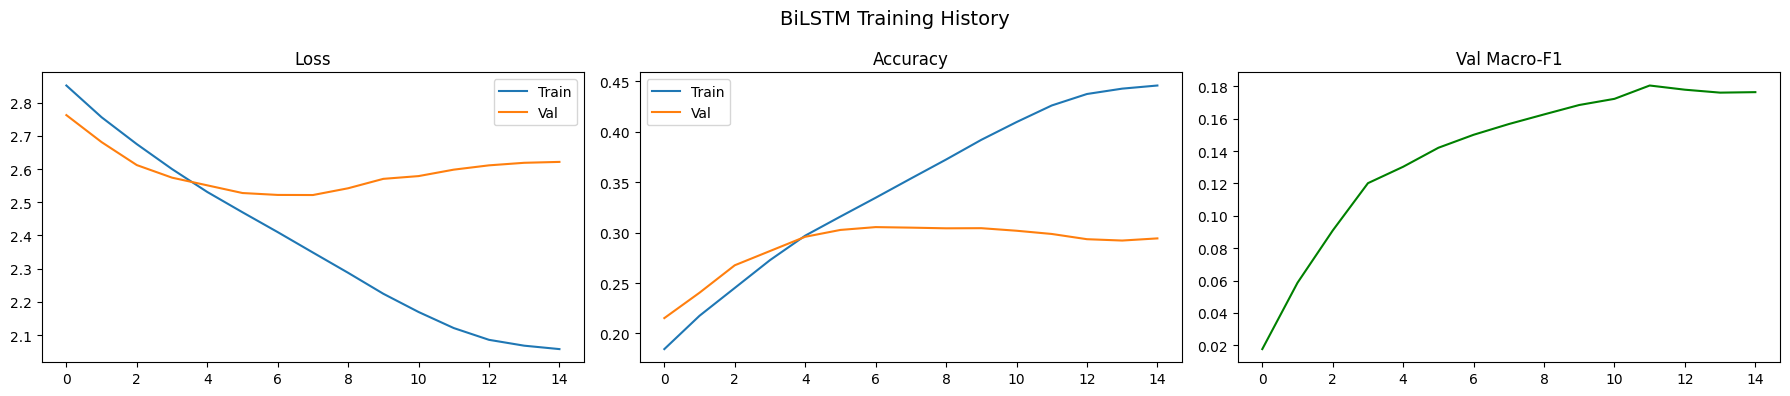


=== BiLSTM Test Results ===
Accuracy : 0.3005
Macro-F1 : 0.1795
BiLSTM saved.


In [4]:
# ============================================================
# SECTION 3: BiLSTM with Attention
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# ── Build vocabulary ─────────────────────────────────────────
MAX_VOCAB = 40_000
MAX_LEN   = 40
PAD_IDX   = 0
UNK_IDX   = 1

all_tokens = [tok for text in train_df['clean_text'] for tok in text.split()]
counter    = Counter(all_tokens)
vocab      = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
word2idx   = {w: i for i, w in enumerate(vocab)}
print(f"Vocabulary size: {len(vocab):,}")

def encode(text, max_len=MAX_LEN):
    tokens = text.split()[:max_len]
    ids    = [word2idx.get(t, UNK_IDX) for t in tokens]
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids

# ── Dataset ──────────────────────────────────────────────────
class TweetDataset(Dataset):
    def __init__(self, df):
        self.X = torch.tensor([encode(t) for t in df['clean_text']], dtype=torch.long)
        self.y = torch.tensor(df['label'].values, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 128
train_loader = DataLoader(TweetDataset(train_df), BATCH, shuffle=True)
val_loader   = DataLoader(TweetDataset(val_df),   BATCH)
test_loader  = DataLoader(TweetDataset(test_df),  BATCH)

# ── BiLSTM model ─────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers, num_classes, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attn    = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        emb     = self.dropout(self.embedding(x))
        out, _  = self.lstm(emb)
        scores  = torch.softmax(self.attn(out), dim=1)
        ctx     = (scores * out).sum(dim=1)
        return self.fc(ctx)

MODEL_LSTM = BiLSTMClassifier(
    vocab_size=len(vocab), embed_dim=128, hidden_dim=256,
    num_layers=2, num_classes=20, dropout=0.35
).to(DEVICE)
print(f"Parameters: {sum(p.numel() for p in MODEL_LSTM.parameters()):,}")

# ── Train / eval helpers ─────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, total_correct = 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss    += loss.item() * len(y)
        total_correct += (logits.argmax(1) == y).sum().item()
    n = len(loader.dataset)
    return total_loss / n, total_correct / n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y  = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss   = criterion(logits, y)
        total_loss    += loss.item() * len(y)
        preds          = logits.argmax(1)
        total_correct += (preds == y).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    n      = len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / n, total_correct / n, macro_f1, all_preds, all_labels

# ── Training loop ─────────────────────────────────────────────
EPOCHS    = 15
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(MODEL_LSTM.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = OneCycleLR(optimizer, max_lr=1e-3,
                       steps_per_epoch=len(train_loader), epochs=EPOCHS)

best_val_f1  = 0
best_weights = None
history      = {'train_loss': [], 'val_loss': [],
                'train_acc': [],  'val_acc': [], 'val_f1': []}

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_epoch(MODEL_LSTM, train_loader, optimizer, criterion, scheduler)
    vl, va, vf1, _, _ = evaluate(MODEL_LSTM, val_loader, criterion)
    for k, v in zip(history, [tl, vl, ta, va, vf1]):
        history[k].append(v)
    if vf1 > best_val_f1:
        best_val_f1  = vf1
        best_weights = {k: v.clone() for k, v in MODEL_LSTM.state_dict().items()}
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss {tl:.4f} Acc {ta:.4f} | Val Loss {vl:.4f} Acc {va:.4f} F1 {vf1:.4f}")

MODEL_LSTM.load_state_dict(best_weights)
print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'],  label='Val'); axes[0].set_title('Loss');     axes[0].legend()
axes[1].plot(history['train_acc'],  label='Train'); axes[1].plot(history['val_acc'],   label='Val'); axes[1].set_title('Accuracy'); axes[1].legend()
axes[2].plot(history['val_f1'], color='green');                                                       axes[2].set_title('Val Macro-F1')
plt.suptitle('BiLSTM Training History', fontsize=14); plt.tight_layout(); plt.show()

# ── Test evaluation ───────────────────────────────────────────
_, test_acc, test_f1, y_pred_lstm, y_true_lstm = evaluate(MODEL_LSTM, test_loader, criterion)
print(f"\n=== BiLSTM Test Results ===")
print(f"Accuracy : {test_acc:.4f}")
print(f"Macro-F1 : {test_f1:.4f}")

# Save model
torch.save({'model_state': MODEL_LSTM.state_dict(), 'word2idx': word2idx,
            'mapping': US_MAPPING,
            'config': {'vocab_size': len(vocab), 'embed_dim': 128,
                       'hidden_dim': 256, 'num_layers': 2,
                       'num_classes': 20, 'dropout': 0.35}}, 'bilstm_model.pt')
print("BiLSTM saved.")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1/5 | Train Loss 2.4845 Acc 0.3020 | Val Acc 0.3796 F1 0.2157
Epoch 2/5 | Train Loss 2.0661 Acc 0.4149 | Val Acc 0.4035 F1 0.2614
Epoch 3/5 | Train Loss 1.8827 Acc 0.4687 | Val Acc 0.4053 F1 0.2745
Epoch 4/5 | Train Loss 1.7371 Acc 0.5124 | Val Acc 0.3981 F1 0.2920
Epoch 5/5 | Train Loss 1.6314 Acc 0.5464 | Val Acc 0.3927 F1 0.2908

Best Val Macro-F1: 0.2920

=== BERTweet Test Results ===
Accuracy : 0.4211
Macro-F1 : 0.2913

                                    precision    recall  f1-score   support

                     ❤ _red_heart_       0.50      0.68      0.58     10798
   😍 _smiling_face_with_hearteyes_       0.31      0.44      0.37      4830
        😂 _face_with_tears_of_joy_       0.48      0.57      0.52      4534
                    💕 _two_hearts_       0.29      0.08      0.13      2605
                          🔥 _fire_       0.62      0.56      0.59      3716
😊 _smiling_face_with_smiling_eyes_       0.17      0.17      0.17      1613
  😎 _smiling_face_with_sunglasse

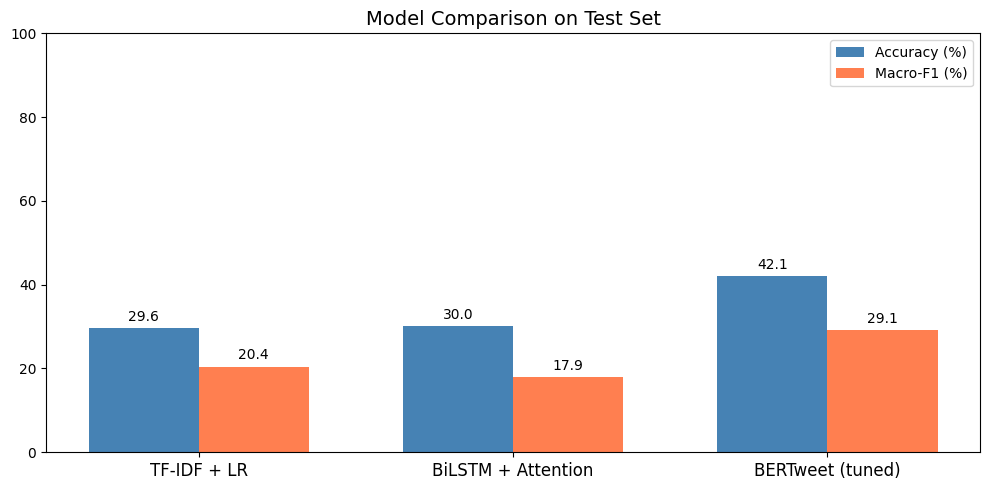

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERTweet saved to bertweet_emoji/

Tweet  : "Just got back from the gym, best workout of my life!"
Model  : bertweet
-------------------------------------------------------
  1. 😍  _smiling_face_with_hearteyes_               21.2%  ████████
  2. 😂  _face_with_tears_of_joy_                    19.9%  ███████
  3. 🔥  _fire_                                      10.4%  ████

Tweet  : "Happy birthday to my best friend, you mean the world to me"
Model  : bertweet
-------------------------------------------------------
  1. ❤  _red_heart_                                 69.8%  ███████████████████████████
  2. 💕  _two_hearts_                                12.0%  ████
  3. 💜  _purple_heart_                               4.7%  █

Tweet  : "The sunset today was absolutely gorgeous"
Model  : bertweet
-------------------------------------------------------
  1. 😍  _smiling_face_with_hearteyes_               76.3%  ██████████████████████████████
  2. ❤  _red_heart_                                  8

In [5]:
# ============================================================
# SECTION 4: BERTweet Fine-tuning + Model Comparison + Demo
# ============================================================

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_linear_schedule_with_warmup)
from sklearn.metrics import (classification_report, precision_recall_fscore_support,
                              f1_score, accuracy_score)
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Tokenizer + Dataset ───────────────────────────────────────
MODEL_NAME = 'vinai/bertweet-base'
TOKENIZER  = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

class BERTweetDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.encodings = tokenizer(list(df['text']), truncation=True,
                                   padding='max_length', max_length=max_len,
                                   return_tensors='pt')
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {'input_ids':      self.encodings['input_ids'][i],
                'attention_mask': self.encodings['attention_mask'][i],
                'labels':         self.labels[i]}

BT_BATCH = 32
bt_train = DataLoader(BERTweetDataset(train_df, TOKENIZER), BT_BATCH, shuffle=True)
bt_val   = DataLoader(BERTweetDataset(val_df,   TOKENIZER), BT_BATCH)
bt_test  = DataLoader(BERTweetDataset(test_df,  TOKENIZER), BT_BATCH)

# ── Model ─────────────────────────────────────────────────────
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=20).to(DEVICE)

BT_EPOCHS    = 5
BT_LR        = 2e-5
bt_optimizer = AdamW(bert_model.parameters(), lr=BT_LR, weight_decay=0.01)
total_steps  = len(bt_train) * BT_EPOCHS
bt_scheduler = get_linear_schedule_with_warmup(bt_optimizer,
                   num_warmup_steps=total_steps // 10,
                   num_training_steps=total_steps)
bt_criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# ── Training loop ─────────────────────────────────────────────
best_bt_f1, best_bt_wts = 0, None

for epoch in range(1, BT_EPOCHS + 1):
    bert_model.train()
    t_loss, t_correct = 0, 0
    for batch in bt_train:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['labels'].to(DEVICE)
        bt_optimizer.zero_grad()
        out  = bert_model(input_ids=ids, attention_mask=mask)
        loss = bt_criterion(out.logits, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        bt_optimizer.step(); bt_scheduler.step()
        t_loss    += loss.item() * len(lbls)
        t_correct += (out.logits.argmax(1) == lbls).sum().item()

    bert_model.eval()
    v_preds, v_labels = [], []
    with torch.no_grad():
        for batch in bt_val:
            out = bert_model(input_ids=batch['input_ids'].to(DEVICE),
                             attention_mask=batch['attention_mask'].to(DEVICE))
            v_preds.extend(out.logits.argmax(1).cpu().numpy())
            v_labels.extend(batch['labels'].numpy())
    vf1  = f1_score(v_labels, v_preds, average='macro')
    vacc = accuracy_score(v_labels, v_preds)
    if vf1 > best_bt_f1:
        best_bt_f1  = vf1
        best_bt_wts = {k: v.clone() for k, v in bert_model.state_dict().items()}
    n = len(bt_train.dataset)
    print(f"Epoch {epoch}/{BT_EPOCHS} | Train Loss {t_loss/n:.4f} Acc {t_correct/n:.4f} | Val Acc {vacc:.4f} F1 {vf1:.4f}")

bert_model.load_state_dict(best_bt_wts)
print(f"\nBest Val Macro-F1: {best_bt_f1:.4f}")

# ── Test evaluation ───────────────────────────────────────────
bert_model.eval()
y_pred_bert, y_true_bert = [], []
with torch.no_grad():
    for batch in bt_test:
        out = bert_model(input_ids=batch['input_ids'].to(DEVICE),
                         attention_mask=batch['attention_mask'].to(DEVICE))
        y_pred_bert.extend(out.logits.argmax(1).cpu().numpy())
        y_true_bert.extend(batch['labels'].numpy())

target_names = [f"{US_MAPPING[i]['emoji']} {US_MAPPING[i]['name']}" for i in range(20)]
print("\n=== BERTweet Test Results ===")
print(f"Accuracy : {accuracy_score(y_true_bert, y_pred_bert):.4f}")
print(f"Macro-F1 : {f1_score(y_true_bert, y_pred_bert, average='macro'):.4f}\n")
print(classification_report(y_true_bert, y_pred_bert, target_names=target_names))

# ── Model comparison chart ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

results = {
    'TF-IDF + LR':         [accuracy_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_lr, average='macro')],
    'BiLSTM + Attention':  [accuracy_score(y_true_lstm, y_pred_lstm),  f1_score(y_true_lstm, y_pred_lstm, average='macro')],
    'BERTweet (tuned)':    [accuracy_score(y_true_bert, y_pred_bert),  f1_score(y_true_bert, y_pred_bert, average='macro')],
}
labels = list(results.keys())
accs   = [v[0]*100 for v in results.values()]
f1s    = [v[1]*100 for v in results.values()]
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)', color='steelblue')
b2 = ax.bar(x + w/2, f1s,  w, label='Macro-F1 (%)', color='coral')
ax.bar_label(b1, fmt='%.1f', padding=3)
ax.bar_label(b2, fmt='%.1f', padding=3)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 100); ax.set_title('Model Comparison on Test Set', fontsize=14)
ax.legend(); plt.tight_layout(); plt.show()

# ── Save BERTweet ─────────────────────────────────────────────
bert_model.save_pretrained('bertweet_emoji')
TOKENIZER.save_pretrained('bertweet_emoji')
print("BERTweet saved to bertweet_emoji/")

# ── Interactive prediction function ──────────────────────────
def predict_emoji(text, model_choice='bertweet', top_k=5):
    print(f'\nTweet  : "{text}"')
    print(f'Model  : {model_choice}')
    print('-' * 55)

    if model_choice == 'lr':
        import re
        clean = re.sub(r'http\S+|@\w+', '', text.lower())
        probs = lr.predict_proba(tfidf.transform([clean]))[0]

    elif model_choice == 'lstm':
        MODEL_LSTM.eval()
        ids = torch.tensor([encode(preprocess_tweet(text))]).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(MODEL_LSTM(ids), -1).cpu().numpy()[0]

    elif model_choice == 'bertweet':
        bert_model.eval()
        enc = TOKENIZER(text, return_tensors='pt', truncation=True,
                        max_length=64, padding='max_length')
        with torch.no_grad():
            logits = bert_model(input_ids=enc['input_ids'].to(DEVICE),
                                attention_mask=enc['attention_mask'].to(DEVICE)).logits
        probs = torch.softmax(logits, -1).cpu().numpy()[0]

    top_idx = np.argsort(probs)[::-1][:top_k]
    for rank, idx in enumerate(top_idx, 1):
        bar = '█' * int(probs[idx] * 40)
        print(f"  {rank}. {US_MAPPING[idx]['emoji']}  "
              f"{US_MAPPING[idx]['name']:<42} {probs[idx]*100:5.1f}%  {bar}")
    return US_MAPPING[top_idx[0]]['emoji']

# ── Demo ──────────────────────────────────────────────────────
demo_tweets = [
    "Just got back from the gym, best workout of my life!",
    "Happy birthday to my best friend, you mean the world to me",
    "The sunset today was absolutely gorgeous",
    "I can't stop laughing at this video it's so funny",
    "Missing home during the holidays",
    "New York City you never disappoint",
]
for tweet in demo_tweets:
    predict_emoji(tweet, model_choice='bertweet', top_k=3)

# ── Interactive widget ────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

tweet_box    = widgets.Textarea(value='Just arrived in New York City!',
                                 layout=widgets.Layout(width='500px', height='70px'))
model_select = widgets.Dropdown(options=['lr','lstm','bertweet'], value='bertweet',
                                 description='Model:')
btn          = widgets.Button(description='Predict Emoji', button_style='primary')
out          = widgets.Output()

def on_click(b):
    with out:
        out.clear_output()
        predict_emoji(tweet_box.value, model_choice=model_select.value, top_k=5)

btn.on_click(on_click)
display(widgets.VBox([widgets.Label('Enter a tweet:'), tweet_box, model_select, btn, out]))